In [72]:
import numpy as np
import random
import matplotlib.pyplot as plt
from neuralnet import avg_fidelity_loss, avg_norm_loss, mse_cyclic
import math

from dataGenNew import generate_random_function, Ugen, rand_En, rand_costheta, rand_phi, full_measure, full_measure_cart, compute_waveplate
from dataGenNew import rand_nx, compute_waveplate_cart

import tensorflow as tf
from keras import backend as K
import time 

# Define Pauli matrices

s1 = np.matrix([[0,1],[1,0]])
s2 = np.matrix([[0,-1j],[1j,0]])
s3 = np.matrix([[1,0],[0,-1]])

Load up trained models

In [73]:
# Load model checkpoint 
num_pix = 16


mol_16 = '16Net_new2'
mol_16_cart = '16Net_cart2_2'
mol_16_cycleLoss = '16Net_cycle'


mol_32 = '32Net_new2'
mol_32_cart = '32Net_cart2_2'

loaded_model = tf.keras.models.load_model(mol_16_cycleLoss, custom_objects={'math': math, 'minMean': avg_fidelity_loss, 'minMeanNormal':avg_norm_loss, 'mse_cyclic':mse_cyclic}, compile=True)
#loaded_model.summary()

# Generate Sample Points

To verify the speed of our modulations, let's generate a single function

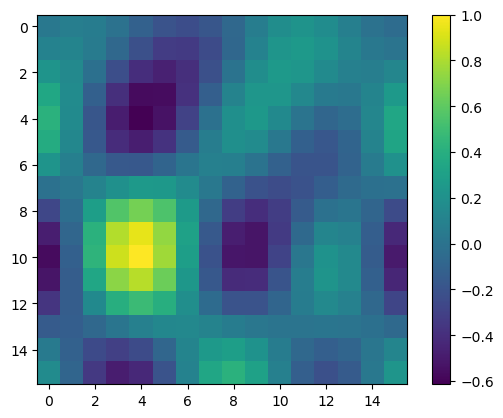

In [74]:
maxAng = math.radians(10)
ang = random.uniform(0,maxAng)
n_coeff = 2
res=num_pix

riggo = rand_nx(n_coeff, res, ang)

plt.imshow(riggo)
plt.colorbar()

Sample at random points from the bloch sphere

In [75]:
# array of zeros (just to test)
n_coeff = np.random.randint(1,1+1)
num_waveplates = 2
num_pix = 16
maxAng = math.radians(10)

isCart2 = False # Are we using the (En, nx, ny) parameterization? 
isPol = True

fac=np.random.uniform(0,0.00001)
#fac = 1

if(isPol):
    a1, a2, a3 = compute_waveplate(num_waveplates, n_coeff, num_pix, maxAng)
    if a2[0,0] > np.pi/2:
        a2=(np.pi-a2)%(np.pi) # theta
        a1=(np.pi-a1)%(np.pi) # En 
        a3=(np.pi+a3)%(2*np.pi) # phi

elif (isCart2):
    a1, a2, a3= compute_waveplate_cart(num_waveplates, n_coeff, num_pix, maxAng, isCart2)
else:
    a1, a2, a3, a4 = compute_waveplate_cart(num_waveplates, n_coeff, num_pix, maxAng, isCart2)
    if a4[0,0]<0 and isCart2==False: #make sure the first pixel has nz>0
        a2*=-1
        a1=(np.pi-a1)%(np.pi)
        a3*=-1
        a4*=-1
    
    
print(f"Number of Waveplates: {num_waveplates} \nNumber of coefficents: {n_coeff}")

Number of Waveplates: 2 
Number of coefficents: 1


C:\Users\freem\Desktop\QPT_NN (OFFLINE)\dataGenNew.py:355: ComplexWarning: Casting complex values to real discards the imaginary part
  En[ind1,ind2] = En_pix
C:\Users\freem\Desktop\QPT_NN (OFFLINE)\dataGenNew.py:356: ComplexWarning: Casting complex values to real discards the imaginary part
  thetapol[ind1,ind2] = thetapol_pix


In [76]:
y_true = np.empty((1,num_pix, num_pix,3))
y_true[0,:,:,0] = a1
y_true[0,:,:,1] = a2
y_true[0,:,:,2] = a3


In [77]:
# How well does our network generalize to noisy data? 

noise = 0.00
stateNoise=0.00

if(isPol):
    full_meas = full_measure(a1,a2,a3,num_pix,noise,stateNoise)
elif(isCart2):
    full_meas=full_measure_cart(a1,a2,a3,num_pix,noise,stateNoise)
else:
    full_meas=full_measure_cart(a1,a2,a3,num_pix,noise,stateNoise, nz=a4)

full_meas_enhance = tf.expand_dims(full_meas, axis=0)

# Make subplots of input data 

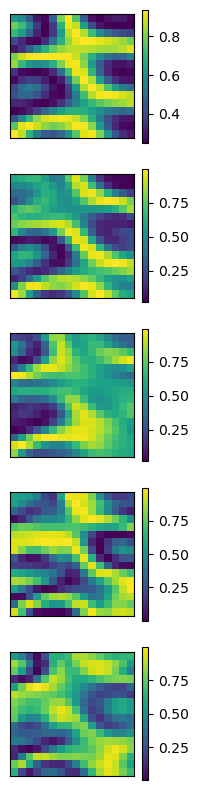

In [78]:
fig, ax = plt.subplots(5,1, figsize=(2,10))


ax[0].imshow(full_meas[:,:,0]) 
ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

ax[1].imshow(full_meas[:,:,1]) 
ax[1].get_xaxis().set_visible(False)
ax[1].get_yaxis().set_visible(False)

ax[2].imshow(full_meas[:,:,2]) 
ax[2].get_xaxis().set_visible(False)
ax[2].get_yaxis().set_visible(False)

ax[3].imshow(full_meas[:,:,3])
ax[3].get_xaxis().set_visible(False)
ax[3].get_yaxis().set_visible(False)

ax[4].imshow(full_meas[:,:,4])
ax[4].get_xaxis().set_visible(False)
ax[4].get_yaxis().set_visible(False)

# Add colorbars to subplots
cb1 = fig.colorbar(ax[0].imshow(full_meas[:,:,0]), ax=ax[0])
cb2 = fig.colorbar(ax[1].imshow(full_meas[:,:,1]), ax=ax[1])
cb3 = fig.colorbar(ax[2].imshow(full_meas[:,:,2]), ax=ax[2])
cb4 = fig.colorbar(ax[3].imshow(full_meas[:,:,3]), ax=ax[3])
cb5 = fig.colorbar(ax[4].imshow(full_meas[:,:,4]), ax=ax[4])




# Make subplots of output data 

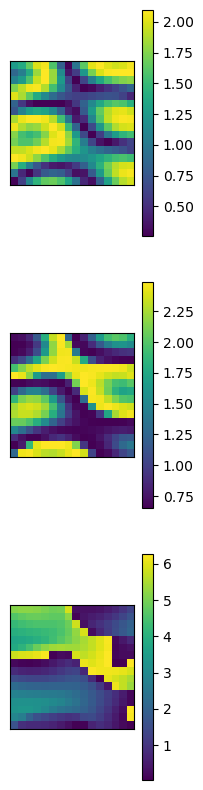

In [86]:
fig, ax = plt.subplots(3,1, figsize=(2,10))

ax[0].imshow(a1) 
ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

ax[1].imshow(a2) 
ax[1].get_xaxis().set_visible(False)
ax[1].get_yaxis().set_visible(False)

ax[2].imshow(a3) 
ax[2].get_xaxis().set_visible(False)
ax[2].get_yaxis().set_visible(False)


# Add colorbars to subplots
cb1 = fig.colorbar(ax[0].imshow(a1), ax=ax[0])
cb2 = fig.colorbar(ax[1].imshow(a2), ax=ax[1])
cb3 = fig.colorbar(ax[2].imshow(a3), ax=ax[2])



'''
ax[3].imshow(a4)
ax[3].get_xaxis().set_visible(False)
ax[3].get_yaxis().set_visible(False)
'''


plt.savefig('outputMeas.png')

An aside: what if we apply phase unwrapping? Let us consider the polar reconstruction

# Now we prompt the network to make predictions

In [80]:
start_time = time.time()
y_pred=loaded_model.predict(full_meas_enhance)
fin_time = time.time() - start_time
print(fin_time)
np.shape(y_pred)

if(isPol):
   # Polar coordinate reconstruction
    print("it is time")
    En_vect=y_pred[0,:,:,0]
    nx_vect=np.sin(y_pred[0,:,:,1])*np.cos(y_pred[0,:,:,2])
    ny_vect=np.sin(y_pred[0,:,:,1])*np.sin(y_pred[0,:,:,2])
    nz_vect=np.cos(y_pred[0,:,:,1])

elif(isCart2):
    nz_vect = np.sqrt(abs(1-nx_vect**2 - ny_vect**2))
else:
    nz_vect = y_pred[0,:,:,3]   

1/1 [==============================] - 1s 519ms/step
0.5562357902526855
it is time


In [81]:
if (isPol):
    # Polar coordinate reconstruction
    print("dog eat dog world")
    E_th_mat=a1
    nx_th_mat=np.sin(a2)*np.cos(a3)
    ny_th_mat=np.sin(a2)*np.sin(a3)
    nz_th_mat=np.cos(a2)
    
elif(isCart2):
    E_th_mat = a1
    nx_th_mat = a2
    ny_th_mat = a3
    nz_th_mat = np.sqrt(abs(1-a2**2 - a3**2)) 
else:
    E_th_mat = a1
    nx_th_mat = a2
    ny_th_mat = a3
    nz_th_mat = a4
    

dog eat dog world


In [82]:
def fidelity(mat1,mat2):
    prod=np.trace(np.dot(np.conjugate(mat1.T),mat2))
    
    return 0.5*np.abs(prod)

def op_par(En,nx,ny,nz):
    mat=np.zeros([2,2],dtype=complex)
    
    mat[0,0]=np.cos(En) - 1j*np.sin(En)*nz
    mat[0,1]=-1j*np.sin(En)*(nx - 1j*ny)
    mat[1,0]=-1j*np.sin(En)*(nx + 1j*ny)
    mat[1,1]=np.cos(En) + 1j*np.sin(En)*nz
    
    return mat

In [83]:
Fvals=np.zeros([num_pix,num_pix])
for i in range(num_pix):
    for j in range(num_pix):
            netU=op_par(En_vect[i,j],nx_vect[i,j],ny_vect[i,j],nz_vect[i,j])
            thU=op_par(E_th_mat[i,j],nx_th_mat[i,j],ny_th_mat[i,j],nz_th_mat[i,j])
            Fvals[i,j]=fidelity(netU,thU)
            print(Fvals[i,j])
            

0.2150028431622106
0.25939809237221256
0.41695758618438805
0.27779087333721075
0.2754861608879556
0.36918609678226655
0.21235481037129494
0.1441784382582157
0.3083504624756198
0.3310747744619916
0.32151190242503364
0.4993500087466105
0.7219065980879674
0.6439933667016967
0.5263342478004958
0.0745281529503044
0.004367909171339536
0.1018257278750265
0.21792951381036677
0.4732185149488386
0.37427095709832725
0.6405694852282728
0.08475167170261187
0.09220071988485949
0.39278979075400755
0.34084102282654405
0.04113530720808279
0.44096098714274057
0.7882055702386608
0.5055052987384471
0.5389190252587772
0.07208193020379389
0.11573955834989724
0.18373900213883146
0.013959536705562214
0.028232201477507907
0.48221358356582594
0.6569300105487785
0.16019340050749964
0.11700824868746909
0.23833520825099602
0.3669267248471107
0.3280644963197145
0.054305181340928294
0.05042889947238206
0.19610795545631754
0.051169373453665026
0.1750091686480764
0.5109719082514487
0.5052655852832908
0.662921471593745

In [84]:
np.mean(Fvals)

0.3263897776339777

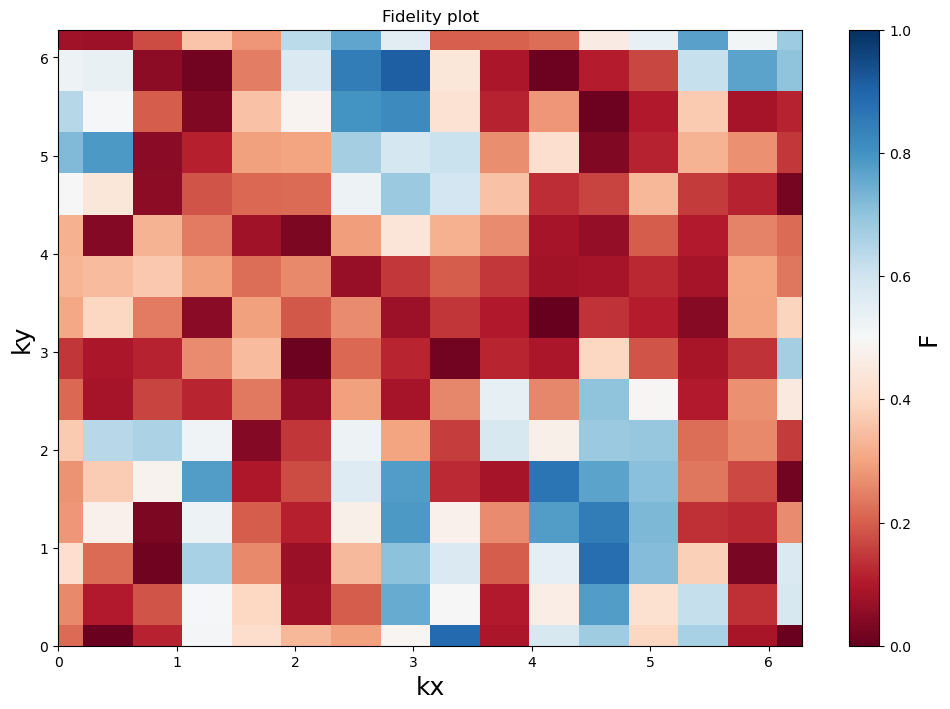

In [85]:
kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)

fig, ax = plt.subplots(figsize=(12, 8))
y,x=np.meshgrid(kxvals,kyvals)

c = ax.pcolormesh(x,y,Fvals, cmap='RdBu', vmin=0, vmax=1)
ax.set_title('Fidelity plot')

# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])

plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)

cbar=fig.colorbar(c, ax=ax)
cbar.set_label('F',fontsize=18)

plt.savefig(f'curr_fidReconstruct_{num_pix}.png')

# How does the network generalize to higher resolution data? 

# Theoretical Data

In [87]:
num_pix
np.shape(E_th_mat[:-1, :-1])

(15, 15)

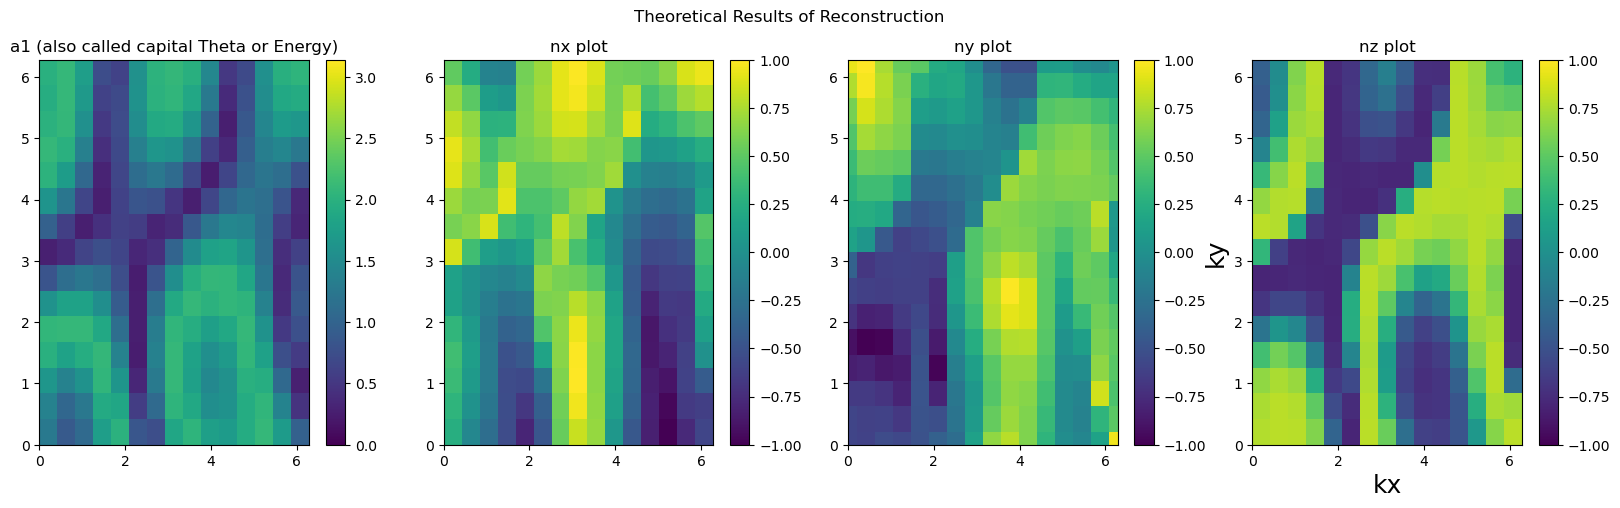

In [88]:
# Let's bind the data with some minima and maxima 

minA1 = 0
maxA1 = np.pi

minNx = -1
maxNx = 1

minNy = -1
maxNy = 1

minNz = -1
maxNz = 1

kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)

fig, ax = plt.subplots(1,4,figsize=(20, 5))
y,x=np.meshgrid(kxvals,kyvals)

plt.suptitle('Theoretical Results of Reconstruction')

c = ax[0].pcolormesh(x, y, E_th_mat[:-1, :-1], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[0])

c2 = ax[1].pcolormesh(x, y, nx_th_mat[:-1, :-1], cmap='viridis', vmin=minNx, vmax=maxNx)
ax[1].set_title('nx plot')
# set the limits of the plot to the limits of the data
ax[1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[1])

c3 = ax[2].pcolormesh(x, y, ny_th_mat, cmap='viridis', vmin=minNy, vmax=maxNy)
ax[2].set_title('ny plot')
# set the limits of the plot to the limits of the data
ax[2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[2])

c4 = ax[3].pcolormesh(x, y, nz_th_mat[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax[3].set_title('nz plot')
# set the limits of the plot to the limits of the data
ax[3].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c4, ax=ax[3])

plt.savefig(f'theoretical_{num_pix}.png')

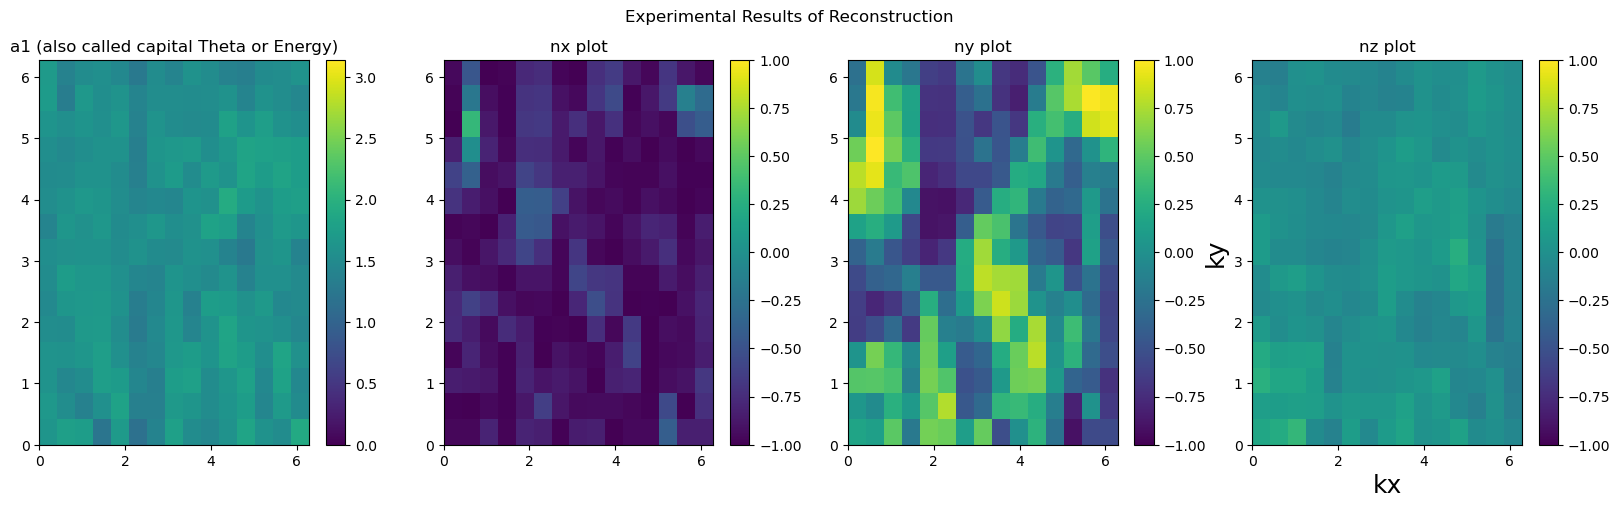

In [89]:
# Let's bind the data with some minima and maxima 

minA1 = 0
maxA1 = np.pi

minNx = -1
maxNx = 1

minNy = -1
maxNy = 1

minNz = -1
maxNz = 1

kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)

fig, ax = plt.subplots(1,4,figsize=(20, 5))
y,x=np.meshgrid(kxvals,kyvals)

plt.suptitle('Experimental Results of Reconstruction')

c = ax[0].pcolormesh(x, y, En_vect[:-1, :-1], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[0])

c2 = ax[1].pcolormesh(x, y, nx_vect[:-1, :-1], cmap='viridis', vmin=minNx, vmax=maxNx)
ax[1].set_title('nx plot')
# set the limits of the plot to the limits of the data
ax[1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[1])

c3 = ax[2].pcolormesh(x, y, ny_vect[:-1,:-1], cmap='viridis', vmin=minNy, vmax=maxNy)
ax[2].set_title('ny plot')
# set the limits of the plot to the limits of the data
ax[2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[2])

c4 = ax[3].pcolormesh(x, y, nz_vect[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax[3].set_title('nz plot')
# set the limits of the plot to the limits of the data
ax[3].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c4, ax=ax[3])

plt.savefig(f'experimental_{num_pix}.png')

What do the predictions on the spherical coordinate eigenstates look like?

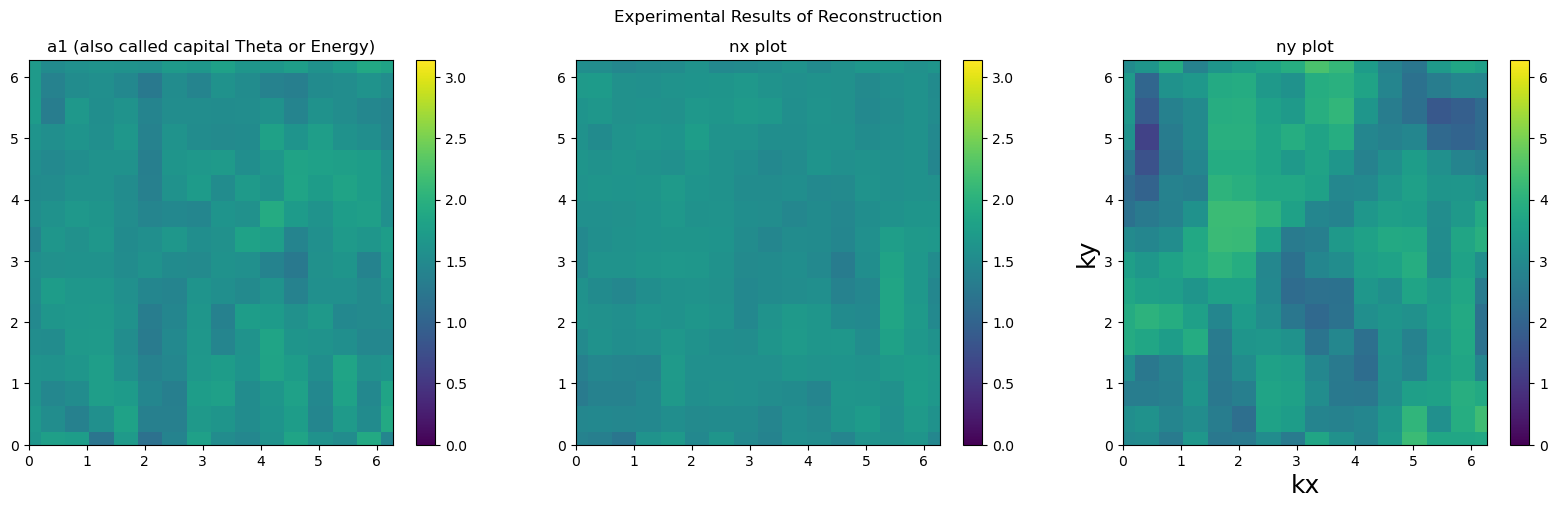

In [90]:
# Let's bind the data with some minima and maxima 

minA1 = 0
maxA1 = np.pi

minTheta = 0
maxTheta = np.pi

minPhi = 0
maxPhi = 2*np.pi

kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)

fig, ax = plt.subplots(1,3,figsize=(20, 5))
y,x=np.meshgrid(kxvals,kyvals)

plt.suptitle('Experimental Results of Reconstruction')

c = ax[0].pcolormesh(x, y, y_pred[0,:,:,0], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[0])

c2 = ax[1].pcolormesh(x, y, y_pred[0,:,:,1], cmap='viridis', vmin=minTheta, vmax=maxTheta)
ax[1].set_title('nx plot')
# set the limits of the plot to the limits of the data
ax[1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[1])

c3 = ax[2].pcolormesh(x, y, y_pred[0,:,:,2], cmap='viridis', vmin=minPhi, vmax=maxPhi)
ax[2].set_title('ny plot')
# set the limits of the plot to the limits of the data
ax[2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[2])


In [ ]:
minNy = 0
maxNy = 1

fig, ax = plt.subplots(figsize=(12, 8))
y,x=np.meshgrid(kxvals,kyvals)

c = ax.pcolormesh(x, y, ny_th_mat, cmap='viridis', vmin=minNy, vmax=maxNy)
ax.set_title('ny plot')
# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax)

plt.savefig('a3_tho.png')

In [ ]:
minNz = 0
maxNz = 1

fig, ax = plt.subplots(figsize=(12, 8))
y,x=np.meshgrid(kxvals,kyvals)

c = ax.pcolormesh(x, y, nz_th_mat[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax.set_title('nz plot')
# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax)

plt.savefig('nz_tho.png')

# Experimental Reconstruction

In [ ]:
kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)


fig, ax = plt.subplots(figsize=(12, 8))
y,x=np.meshgrid(kxvals,kyvals)

c = ax.pcolormesh(x, y, En_vect[:-1, :-1], cmap='viridis', vmin=minA1, vmax=maxA1)
ax.set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax)

plt.savefig('a1_expt.png')

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
y,x=np.meshgrid(kxvals,kyvals)

c = ax.pcolormesh(x, y, nx_vect[:-1, :-1], cmap='viridis', vmin=minNx, vmax=maxNx)
ax.set_title('nx plot')
# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax)

plt.savefig('a2_expt.png')

In [ ]:
#nx_vect
#nx_th_mat

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
y,x=np.meshgrid(kxvals,kyvals)

c = ax.pcolormesh(x, y, ny_vect[:-1, :-1], cmap='viridis', vmin=minNy, vmax=maxNy)
ax.set_title('ny plot')
# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax)

plt.savefig('a3_expt.png')

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
y,x=np.meshgrid(kxvals,kyvals)

c = ax.pcolormesh(x, y, nz_vect[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax.set_title('nz plot')
# set the limits of the plot to the limits of the data
ax.axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax)

plt.savefig('nz_expt.png')

# Appendix: Let's now consider some synthetic experiments

In [ ]:
direc_1 = [f'synthetic_experiments_32/{ii}/' for ii in range(1,9)] # Synthetic experiments
synth = 1

if (synth==5):
    a2 = np.ones((num_pix,num_pix))*np.pi/2
else:
    a2 = np.loadtxt(direc_1[synth-1]+'theta.txt')
    
a1 = np.loadtxt(direc_1[synth-1]+'en.txt')
a3 = np.loadtxt(direc_1[synth-1]+'phi.txt')

LL = np.loadtxt(direc_1[synth-1]+'LL.txt')
LH = np.loadtxt(direc_1[synth-1]+'LH.txt')
LD = np.loadtxt(direc_1[synth-1]+'LD.txt')
HH = np.loadtxt(direc_1[synth-1]+'HH.txt')
HD = np.loadtxt(direc_1[synth-1]+'HD.txt')

full_meas = np.empty((num_pix,num_pix,5))

for i in range(num_pix):
    for j in range(num_pix):
        full_meas[i,j,0] = LL[i,j]
        full_meas[i,j,1] = LH[i,j]
        full_meas[i,j,2] = LD[i,j]
        full_meas[i,j,3] = HH[i,j]
        full_meas[i,j,4] = HD[i,j]


full_meas_enhance = tf.expand_dims(full_meas, axis=0)